```{thebe-button} Live Code
```

Starts a Binder kernel (CPU NumPy; no GPU). When the kernel is ready, click **Run** on each
code cell below. The first cell runs automatically to import `spd` and set up plotting.

# SPD: Introduction and user guide

`spd` solves systems of conservation laws with a high-order **Spectral Difference (SD)**
scheme, stabilized where needed by a low-order **finite-volume (MUSCL) fallback**, on
CPU (NumPy) or GPU (CuPy).

The main axes of configuration are:

| Axis | Knob | Options |
|---|---|---|
| Equations | `soe` | `"hydro"`, `"induction"`, `"mhd"` |
| Spatial scheme | `scheme` | `"SD"`, `"SDFB"` (SD + fallback), `"FV"` |
| Space order | `p` | polynomial degree; the scheme is order `p+1` |
| Time integrator | `time_integrator` | `"ader"` (default), `"rk1"` ... `"rk5"` |
| Dimension | `N` | `(Nx,)`, `(Nx, Ny)`, `(Nx, Ny, Nz)` |
| Riemann solver | `riemann_solver` (or `_ho` / `_lo`) | `"llf"`, `"hllc"` (hydro), `"hlld"` (MHD) |
| Slope limiter | `slope_limiter` | `"minmod"`, `"moncen"` |
| Fallback reconstruction | `fallback` | `"MUSCL"`, `"MUSCL-Hancock"` |
| Limiting strategy | `blending`, `godunov`, `max_revs` | theta-blend / MOOD cascade / pure Godunov |

This notebook walks through every knob on small, fast problems.
The companion notebooks apply them:

- **[Hydro tutorial](../tutorials/hydro)** -- all bundled hydro initial conditions,
- **[Induction tutorial](../tutorials/induction)** -- constrained-transport induction solver,
- **[MHD tutorial](../tutorials/mhd)** -- coupled MHD (Orszag-Tang vortex).

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import spd
import spd.utils.visualization as vsd
import spd.initial_conditions as ic
from spd.spd_simulator import SPD_Simulator

try:
    import cupy as cp
    gpu = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    cp = None
    gpu = False

np.seterr(all="ignore");
mpl.rcParams["font.size"] = 13
print(f"backend: {'cupy (GPU)' if gpu else 'numpy (CPU)'}")

backend: cupy (GPU)


## 1. Entry point

`SPD_Simulator` is a factory: the `soe` keyword ("system of equations") dispatches to
`HydroSimulator` (default), `InductionSimulator`, or `MHDSimulator`, forwarding all
other arguments. You can also import those classes directly.

## 2. Quick start: Sod shock tube

Defaults: `soe="hydro"`, `scheme="SDFB"` (SD with fallback), `time_integrator="ader"`,
`p=1`. Initial conditions are callables `f(xyz, var)`; the bundled ones in
`spd.initial_conditions` are factories, so call them (optionally with parameters) to
get the function: `ic.sod()`, `ic.step_function(vx=2)`, ...

`N` counts SD *elements*; each element carries `(p+1)` solution points per dimension,
so the resolution in degrees of freedom is `N*(p+1)`.

t=0.2, steps taken 139, time taken 3.205, bzcps = 0.0


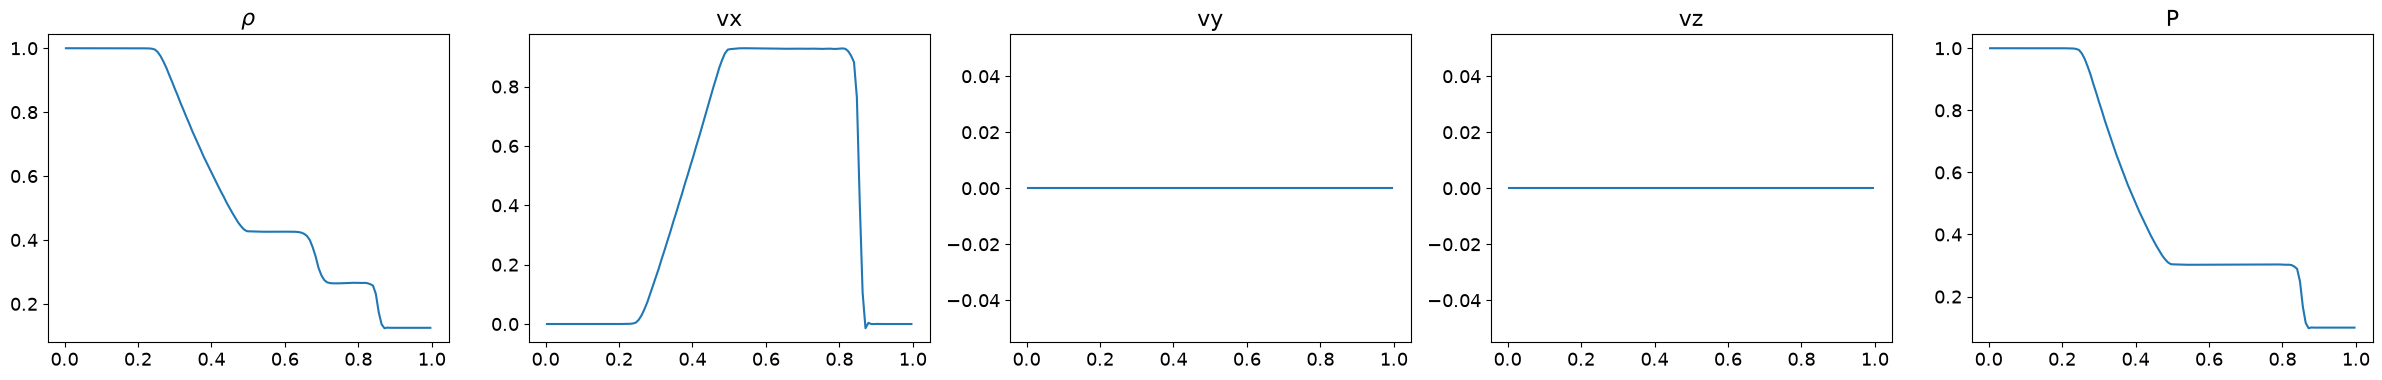

In [2]:
s = SPD_Simulator(
    p=3,                # degree 3 -> 4th order in space
    N=(32,),            # 32 elements x 4 solution points = 128 DOF
    init_fct=ic.sod(),
    BC=(("gradfree", "gradfree"),),   # outflow at both ends
    use_cupy=gpu,
)
s.perform_time_evolution(0.2)
vsd.plot_fields(s, s.dm.W_cv)   # primitive variables: rho, vx, vy, vz, P

The solution lives in the data manager `s.dm`:

- `s.dm.W_cv` / `s.dm.U_cv` -- primitive / conserved control-volume averages,
- rows are indexed by `s.variables` (density `s._d_ = 0`, velocities `s.vels`,
  pressure `s._p_`).

`perform_time_evolution(t_end)` runs to a fixed time; `perform_iterations(n)` runs a
fixed number of steps.

## 3. `scheme`: SD, SDFB, FV

- `"SD"` -- pure high-order spectral difference. Crisp on smooth flows, oscillates at shocks.
- `"SDFB"` -- SD plus the MUSCL fallback: troubled cells are detected each step and
  their fluxes replaced/blended with a robust low-order scheme. **Recommended default.**
- `"FV"` -- pure second-order MUSCL / MUSCL-Hancock finite volume on `N` cells
  (use an RK integrator for FV).

The `FB` boolean is a convenience flag: `FB=False` strips the fallback from the scheme
name, `FB=True` adds it.

t=0.2, steps taken 145, time taken 0.712, bzcps = 0.0


t=0.2, steps taken 139, time taken 2.435, bzcps = 0.0


t=0.2, steps taken 130, time taken 0.319, bzcps = 0.0


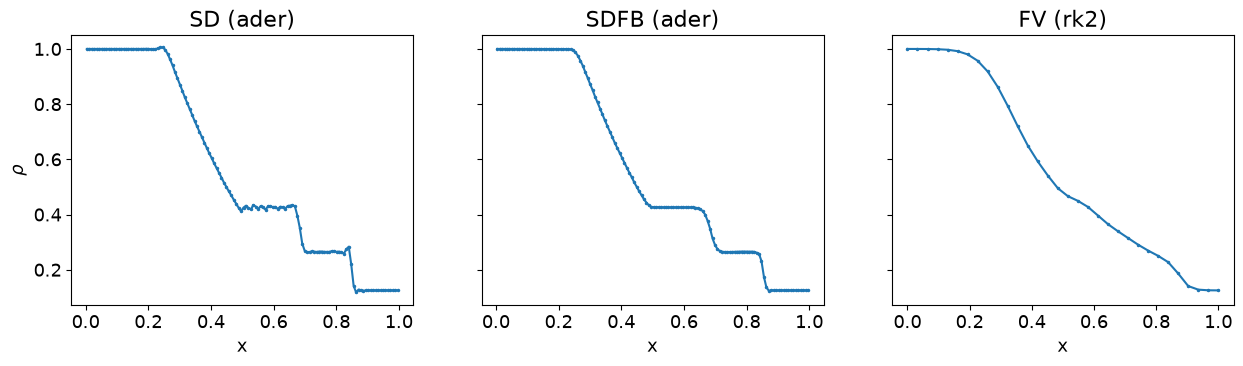

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
runs = [("SD", "ader"), ("SDFB", "ader"), ("FV", "rk2")]
for ax, (scheme, ti) in zip(axs, runs):
    s = SPD_Simulator(p=3, N=(32,), scheme=scheme, time_integrator=ti,
                      init_fct=ic.sod(), BC=(("gradfree", "gradfree"),),
                      use_cupy=gpu, verbose=False)
    s.perform_time_evolution(0.2)
    W = s.transpose_to_fv(s.regular_mesh(s.dm.W_cv))
    x = s.regular_centers()[0] if scheme != "FV" else np.linspace(0, 1, W.shape[1])
    ax.plot(x, W[0], ".-", ms=3)
    ax.set_title(f"{scheme} ({ti})")
    ax.set_xlabel("x")
axs[0].set_ylabel(r"$\rho$");

Pure SD rings at the shock, SDFB stays clean at high order, FV is robust but more
diffusive.

## 4. `p` and `m`: space and time order

`p` is the polynomial degree per element (space order `p+1`). `m` is the time order;
by default `m = p`. For RK integrators the digit in the name sets the order
(`"rk3"` = 3 stages, up to `"rk5"`).

Compare orders at *fixed degrees of freedom* -- higher `p` on fewer elements resolves
smooth features better. At the deliberately coarse 32 DOF below, `p=1` visibly damps
the wave after one period while `p=3` and `p=7` sit on the exact curve:

t=1.0, steps taken 210, time taken 2.216, bzcps = 0.0


t=1.0, steps taken 214, time taken 3.633, bzcps = 0.0


t=1.0, steps taken 214, time taken 6.004, bzcps = 0.0


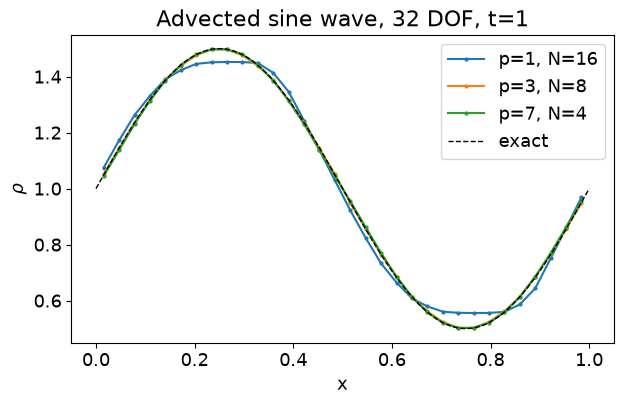

In [4]:
NDOF = 32
plt.figure(figsize=(7, 4))
for p in (1, 3, 7):
    N = NDOF // (p + 1)
    s = SPD_Simulator(p=p, N=(N,), init_fct=ic.sine_wave(A=0.5),
                      use_cupy=gpu, verbose=False)
    s.perform_time_evolution(1.0)   # one advection period
    W = s.transpose_to_fv(s.regular_mesh(s.dm.W_cv))
    plt.plot(s.regular_centers()[0], W[0], ".-", ms=4, label=f"p={p}, N={N}")
x = np.linspace(0, 1, 400)
plt.plot(x, 1 + 0.5*np.sin(2*np.pi*x), "k--", lw=1, label="exact")
plt.legend(); plt.xlabel("x"); plt.ylabel(r"$\rho$")
plt.title(f"Advected sine wave, {NDOF} DOF, t=1");

## 5. `time_integrator`: ADER or Runge-Kutta

- `"ader"` (default) -- single-step, arbitrary-order ADER predictor/corrector.
  The fallback then defaults to `fallback="MUSCL-Hancock"` (its half-step time
  prediction matches the ADER update).
- `"rk1"` ... `"rk5"` -- explicit method-of-lines RK. The fallback defaults to
  plain `fallback="MUSCL"` (a pure spatial RHS).

You can override the fallback reconstruction explicitly with
`fallback="MUSCL"` or `"MUSCL-Hancock"`.

Note: pure-FV hydro and MHD schemes want RK integrators (`"FV"` + ADER is not wired up).

In [5]:
for ti in ("ader", "rk3"):
    s = SPD_Simulator(p=3, N=(32,), time_integrator=ti, init_fct=ic.sod(),
                      BC=(("gradfree", "gradfree"),), use_cupy=gpu, verbose=False)
    s.perform_time_evolution(0.2)
    print(f"{ti:5s}: fallback={s.lo_scheme.scheme!r:16s} steps={s.n_step}")

t=0.2, steps taken 139, time taken 2.308, bzcps = 0.0
ader : fallback='MUSCL-Hancock'  steps=139


t=0.2, steps taken 139, time taken 1.847, bzcps = 0.0
rk3  : fallback='MUSCL'          steps=139


## 6. Dimension

The length of `N` sets the dimension. Boundary conditions (`BC`), limits
(`xlim`/`ylim`/`zlim`) and the plotting helpers follow along.

t=0.5, steps taken 699, time taken 21.926, bzcps = 0.001


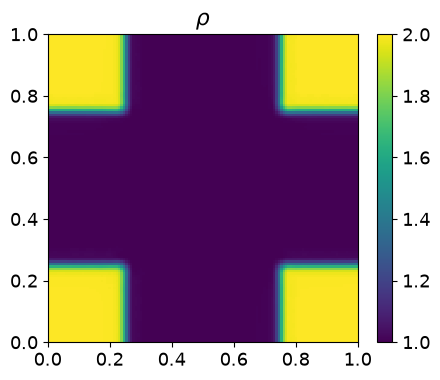

In [6]:
# 2D
s = SPD_Simulator(p=3, N=(32, 32), init_fct=ic.step_function(),
                  use_cupy=gpu, verbose=False)
s.perform_time_evolution(0.5)
plt.figure(figsize=(5, 4)); vsd.plot_field(s, s.dm.W_cv, 0)

t=0.009542492864664999, steps taken 5, time taken 0.239, bzcps = 0.001


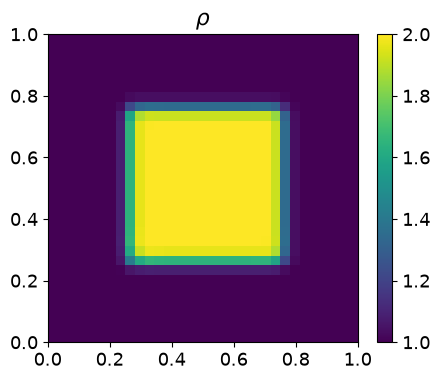

In [7]:
# 3D (small, one step -- just to show the shape conventions)
s = SPD_Simulator(p=1, N=(16, 16, 16), init_fct=ic.step_function(),
                  use_cupy=gpu, verbose=False)
s.perform_iterations(5)
plt.figure(figsize=(5, 4))
vsd.plot_field(s, s.dm.W_cv, 0, dim="z")   # mid-plane slice; integrate=True averages

## 7. Riemann solvers

`riemann_solver` sets the interface flux everywhere. For finer control there are
separate knobs for the two schemes -- when `riemann_solver` is given it supersedes
both:

- `riemann_solver_ho` -- flux of the primary (high-order) scheme,
- `riemann_solver_lo` -- flux of the low-order fallback scheme.

Options: `"llf"` (local Lax-Friedrichs, most diffusive, most robust), `"hllc"`
(hydro only), `"hlld"` (MHD only; see the [MHD tutorial](../tutorials/mhd)).

t=0.2, steps taken 136, time taken 0.33, bzcps = 0.0


t=0.2, steps taken 136, time taken 0.71, bzcps = 0.0


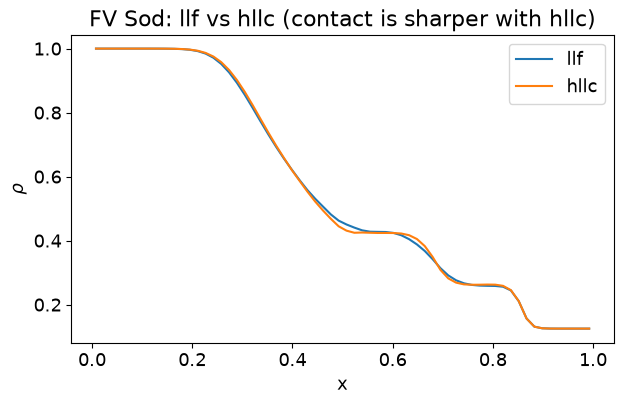

In [8]:
plt.figure(figsize=(7, 4))
for rs in ("llf", "hllc"):
    s = SPD_Simulator(p=1, N=(64,), scheme="FV", time_integrator="rk2",
                      riemann_solver=rs, init_fct=ic.sod(),
                      BC=(("gradfree", "gradfree"),), use_cupy=gpu, verbose=False)
    s.perform_time_evolution(0.2)
    plt.plot(s.regular_centers()[0], s.transpose_to_fv(s.dm.W_cv)[0], label=rs)
plt.legend(); plt.xlabel("x"); plt.ylabel(r"$\rho$")
plt.title("FV Sod: llf vs hllc (contact is sharper with hllc)");

## 8. `slope_limiter`: minmod or moncen

Limits the MUSCL slopes of the FV/fallback reconstruction. `"minmod"` is the most
dissipative and safest; `"moncen"` (monotonized-central) is sharper.

t=0.2, steps taken 136, time taken 0.664, bzcps = 0.0


t=0.2, steps taken 138, time taken 0.672, bzcps = 0.0


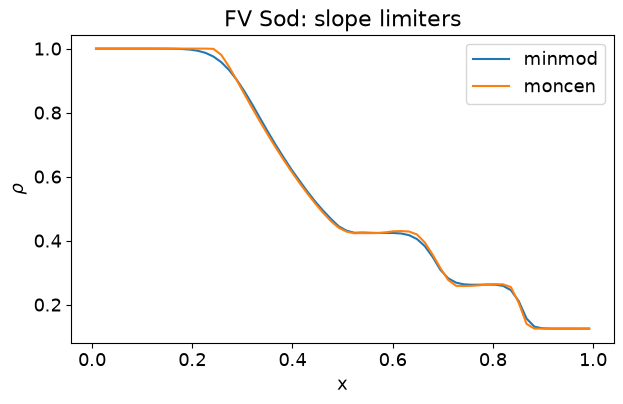

In [9]:
plt.figure(figsize=(7, 4))
for sl in ("minmod", "moncen"):
    s = SPD_Simulator(p=1, N=(64,), scheme="FV", time_integrator="rk2",
                      riemann_solver="hllc", slope_limiter=sl,
                      init_fct=ic.sod(), BC=(("gradfree", "gradfree"),),
                      use_cupy=gpu, verbose=False)
    s.perform_time_evolution(0.2)
    plt.plot(s.regular_centers()[0], s.transpose_to_fv(s.dm.W_cv)[0], label=sl)
plt.legend(); plt.xlabel("x"); plt.ylabel(r"$\rho$"); plt.title("FV Sod: slope limiters");

## 9. Trouble detection (the "FB" in SDFB)

After each candidate update the fallback checks every control volume:

- **NAD** (numerical admissibility): the new value must stay inside the local
  min/max bounds of the previous solution, relaxed by `tolerance`.
  - `NAD=""` -- relative tolerance; `NAD="delta"` -- tolerance scaled by the global range.
  - `NAD_neighbors="1st"` (face neighbors) or `"2nd"` (includes diagonals) sets the
    bounds stencil.
  - `SED=True` -- smooth-extrema detection: genuine smooth extrema are *not* flagged
    (prevents clipping of smooth peaks).
- **PAD** (physical admissibility): flags densities/pressures outside
  `[min_rho, max_rho]` / `min_P` (and NaNs).
- `limiting_variables` -- which rows are NAD-checked (default: density and pressure,
  `[0, 4]`). For more aggressive limiting include the velocities, e.g. `[0, 1, 2, 4]`.

The trouble mask of the last step is in `s.lo_scheme.dm.troubles`:

t=0.8, steps taken 1126, time taken 27.782, bzcps = 0.001


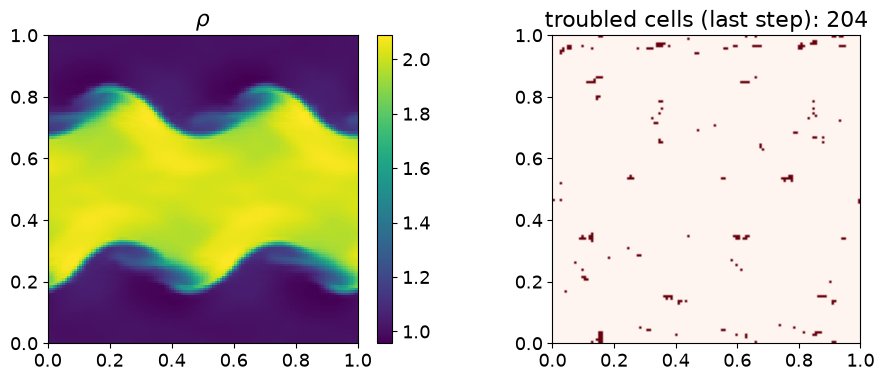

In [10]:
s = SPD_Simulator(p=3, N=(32, 32), init_fct=ic.KH_instability(),
                  time_integrator="rk3", tolerance=1e-5, use_cupy=gpu, verbose=False)
s.perform_time_evolution(0.8)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
plt.sca(axs[0]); vsd.plot_field(s, s.dm.W_cv, 0)
tr = s.dm.asnumpy(s.lo_scheme.dm.troubles)[0]
axs[1].imshow(tr, origin="lower", cmap="Reds", extent=(0, 1, 0, 1))
axs[1].set_title(f"troubled cells (last step): {int(tr.sum())}");

## 10. Limiting strategy: blend, MOOD, or Godunov

What happens to flagged cells is set by two booleans:

| `blending` | `godunov` | behaviour |
|---|---|---|
| `True` (default) | `False` | **theta-blend**: one sweep; high- and low-order fluxes are convex-combined, and the trouble indicator is spread to neighbors with decaying weights (0.75 faces / 0.5 edges / 0.375 corners) |
| `False` | `False` | **MOOD cascade**: iterative detect -> recompute; flagged cells drop to MUSCL, then to first order. `max_revs` caps the number of revision sweeps (the "revisions" knob) |
| -- | `True` | **pure Godunov**: the fallback flux is used everywhere (robust baseline, order ~2) |

t=0.2, steps taken 139, time taken 1.818, bzcps = 0.0


t=0.2, steps taken 139, time taken 3.028, bzcps = 0.0


t=0.2, steps taken 138, time taken 1.029, bzcps = 0.0


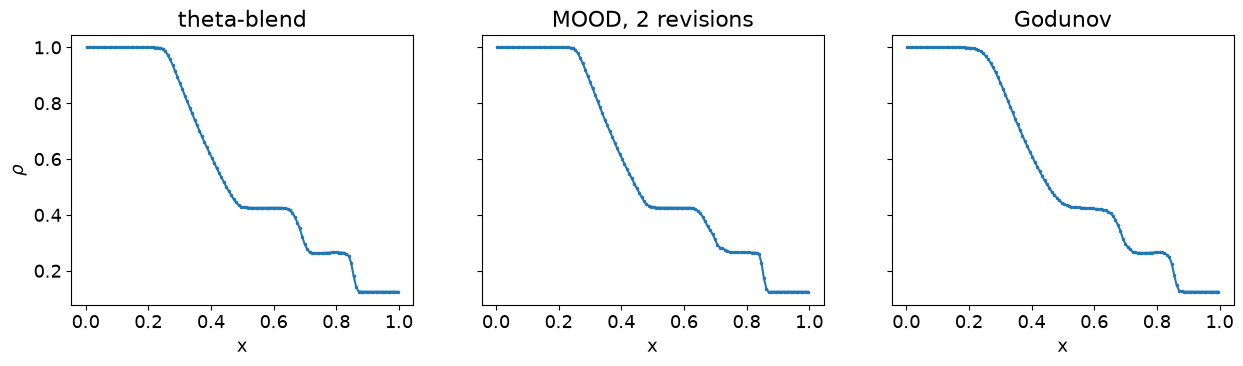

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
configs = [
    ("theta-blend", dict(blending=True)),
    ("MOOD, 2 revisions", dict(blending=False, max_revs=2)),
    ("Godunov", dict(godunov=True)),
]
for ax, (name, kw) in zip(axs, configs):
    s = SPD_Simulator(p=3, N=(32,), init_fct=ic.sod(),
                      BC=(("gradfree", "gradfree"),),
                      time_integrator="rk3", use_cupy=gpu, verbose=False, **kw)
    s.perform_time_evolution(0.2)
    W = s.transpose_to_fv(s.regular_mesh(s.dm.W_cv))
    ax.plot(s.regular_centers()[0], W[0], ".-", ms=3)
    ax.set_title(name); ax.set_xlabel("x")
axs[0].set_ylabel(r"$\rho$");

## 11. Boundary conditions

`BC` is a per-dimension tuple of `(left, right)` strings:

- `"periodic"` (default)
- `"reflective"` -- wall (normal velocity flipped)
- `"gradfree"` -- zero-gradient outflow
- `"doublemach"` -- special time-dependent BCs of the Double Mach Reflection test

Domain extents are `xlim`, `ylim`, `zlim` (default `(0, 1)` each).

The Liska-Wendroff implosion is the classic workout for reflective walls: a
low-pressure corner triangle launches a shock that keeps bouncing around the box.
Because the setup is symmetric about the diagonal, any asymmetry the scheme (or the
BCs) introduces is immediately visible.

t=0.5, steps taken 1938, time taken 49.718, bzcps = 0.001
diagonal symmetry: max|rho - rho^T| = 3.33e-15


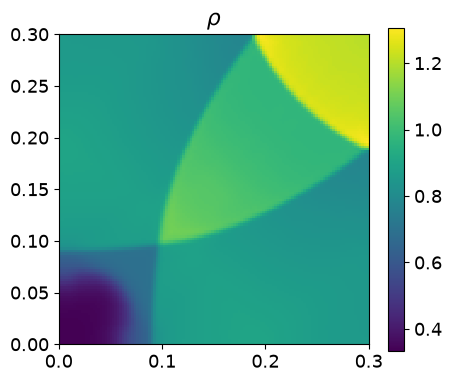

In [12]:
# Liska-Wendroff implosion: reflective walls on all four sides
s = SPD_Simulator(p=3, N=(32, 32), init_fct=ic.implosion(),
                  xlim=(0, 0.3), ylim=(0, 0.3), gamma=1.4,
                  BC=(("reflective", "reflective"), ("reflective", "reflective")),
                  time_integrator="rk3", use_cupy=gpu, verbose=False)
s.perform_time_evolution(0.5)
plt.figure(figsize=(5, 4.2)); vsd.plot_field(s, s.dm.W_cv, 0)
plt.gca().set_aspect("equal")

W = s.dm.asnumpy(s.transpose_to_fv(s.regular_mesh(s.dm.W_cv)))
print(f"diagonal symmetry: max|rho - rho^T| = {np.abs(W[0] - W[0].T).max():.2e}")

## 12. Physics and numerics parameters

- `gamma` -- adiabatic index (default 1.4).
- `cfl_coeff` -- CFL number (default 0.4; for `scheme="FV"` it is divided by `p+1`
  internally).
- `min_rho`, `min_c2` -- floors used in primitive conversions.
- `passives` -- list of passive-scalar names, advected with the flow and appended
  to the variable vector.
- `potential=True` -- static gravity; the potential is sampled from `init_fct(xyz, -1)`
  (see RTI in the [Hydro tutorial](../tutorials/hydro)).
- `WB=True` -- well-balanced mode: evolves the perturbation around an equilibrium
  given by `eq_fct` (hydrostatic setups stay exactly steady).
- `viscosity` / `nu` and `thdiffusion` / `chi` -- Navier-Stokes viscous flux and
  thermal diffusion terms (this code path is currently being reworked -- expect
  rough edges).

t=0.8, steps taken 1126, time taken 35.123, bzcps = 0.001


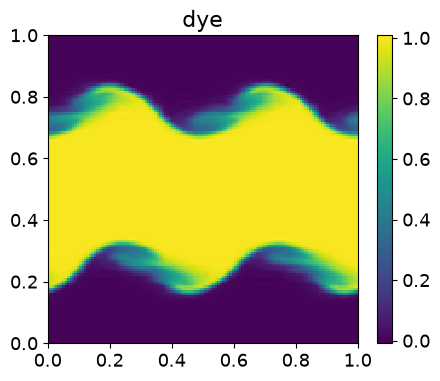

In [13]:
# A passive scalar tracing the initial top/bottom split of a KH run
def kh_with_dye(xyz, var):
    if var == 5:
        return np.where(np.abs(xyz[1] - 0.5) < 0.25, 1.0, 0.0)
    return ic.KH_instability()(xyz, var)

s = SPD_Simulator(p=3, N=(32, 32), init_fct=kh_with_dye, passives=["dye"],
                  time_integrator="rk3", use_cupy=gpu, verbose=False)
s.perform_time_evolution(0.8)
plt.figure(figsize=(5, 4)); vsd.plot_field(s, s.dm.W_cv, 5)

## 13. GPU execution

`use_cupy=True` keeps every array on the GPU for the whole run (CuPy); results are
copied back to host at the end. If CuPy is not installed the flag silently falls
back to NumPy. `verbose=False` suppresses the per-100-step progress line.

The final printout reports wall time and throughput (`bzcps` = billions of
zone-cycles per second).

In [14]:
if gpu:
    s = SPD_Simulator(p=3, N=(64, 64), init_fct=ic.step_function(),
                      time_integrator="rk3", use_cupy=True, verbose=False)
    s.perform_time_evolution(0.2)   # prints steps, wall time, bzcps

t=0.2, steps taken 559, time taken 13.839, bzcps = 0.003


## 14. Outputs and visualization

- `s.output()` writes `W_cv` snapshots to `folder` (default `outputs/`);
  `s.load_output()` restores the latest one.
- `vsd.plot_field(s, M, var)` plots one variable (2D pcolormesh / 1D line;
  for 3D pass `dim=` for the slice normal or `integrate=True`).
- `vsd.plot_fields(s, M)` plots all variables side by side.
- `s.regular_mesh(W)` interpolates SD solution points onto a regular grid, and
  `s.transpose_to_fv(M)` flattens the element layout `(nvar, Ny, Nx, ny, nx)` to a
  plain image `(nvar, Ny*ny, Nx*nx)` -- useful for custom plotting, as in the cells
  above.

## Where next

- **[Hydro tutorial](../tutorials/hydro)** -- Sod, sine wave (convergence), step function,
  Kelvin-Helmholtz, Rayleigh-Taylor with gravity, Double Mach Reflection.
- **[Induction tutorial](../tutorials/induction)** -- the constrained-transport induction
  solver: field-loop advection, SD vs FV, div(B) = 0.
- **[MHD tutorial](../tutorials/mhd)** -- full MHD: Orszag-Tang with the SDFB/MOOD scheme,
  HLLD, and the FV CT scheme.